# Clasificación de Imágenes: Gatos vs Perros
## Transferencia de Aprendizaje con MobileNetV2

In [1]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
import numpy as np
import matplotlib.pyplot as plt
import os
import pathlib
from PIL import Image
import random

## 1. Cargar dataset con validación de imágenes

In [2]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

def cargar_imagenes_validas(carpeta):
    """Carga solo imágenes que TensorFlow puede decodificar"""
    imagenes = []
    etiquetas = []
    clases = {'Gatos': 0, 'Perros': 1}
    
    for clase, idx in clases.items():
        ruta_clase = os.path.join(carpeta, clase)
        if not os.path.exists(ruta_clase):
            continue
        
        archivos = os.listdir(ruta_clase)
        random.shuffle(archivos)
        
        for archivo in archivos:
            ruta_completa = os.path.join(ruta_clase, archivo)
            if not os.path.isfile(ruta_completa):
                continue
            
            # Verificar que sea imagen válida con PIL
            try:
                with Image.open(ruta_completa) as img:
                    img.load()
                    img = img.convert('RGB')
                    img = img.resize(IMG_SIZE)
                    arr = np.array(img, dtype=np.float32) / 255.0
                    if arr.shape == (224, 224, 3):
                        imagenes.append(arr)
                        etiquetas.append(idx)
            except Exception as e:
                pass
    
    return np.array(imagenes), np.array(etiquetas)

print("Cargando imágenes...")
X, y = cargar_imagenes_validas('.')
print(f"Total imágenes válidas: {len(X)}")

# One-hot encoding
y_onehot = tf.keras.utils.to_categorical(y, num_classes=2)

# Mezclar
indices = np.arange(len(X))
np.random.shuffle(indices)
X = X[indices]
y_onehot = y_onehot[indices]

# Dividir 80/20
split = int(0.8 * len(X))
X_train, X_val = X[:split], X[split:]
y_train, y_val = y_onehot[:split], y_onehot[split:]

print(f"Entrenamiento: {len(X_train)} imágenes")
print(f"Validación: {len(X_val)} imágenes")

Cargando imágenes...


C:\Users\JC\AppData\Roaming\Python\Python313\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Total imágenes válidas: 24998
Entrenamiento: 19998 imágenes
Validación: 5000 imágenes


In [3]:
train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(BATCH_SIZE).shuffle(1000).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)

## 2. Modelo pre-entrenado (MobileNetV2)

## 3. Agregar capas de clasificación

In [4]:
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(224, 224, 3))
base_model.trainable = False

In [5]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.3)(x)
predictions = Dense(2, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=Adam(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,210 (9.24 MB)

 Trainable params: 164,226 (641.51 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 4. Entrenar el modelo

In [6]:
epocas = 10

history = model.fit(train_ds, epochs=epocas, validation_data=val_ds)

Epoch 1/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 410s 330ms/step - accuracy: 0.9754 - loss: 0.0652 - val_accuracy: 0.9840 - val_loss: 0.0451
Epoch 2/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 242s 312ms/step - accuracy: 0.9840 - loss: 0.0414 - val_accuracy: 0.9830 - val_loss: 0.0432
Epoch 3/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 308ms/step - accuracy: 0.9871 - loss: 0.0364 - val_accuracy: 0.9822 - val_loss: 0.0472
Epoch 4/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 226s 310ms/step - accuracy: 0.9890 - loss: 0.0307 - val_accuracy: 0.9848 - val_loss: 0.0438
Epoch 5/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 241s 316ms/step - accuracy: 0.9901 - loss: 0.0278 - val_accuracy: 0.9836 - val_loss: 0.0526
Epoch 6/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 232s 311ms/step - accuracy: 0.9916 - loss: 0.0236 - val_accuracy: 0.9824 - val_loss: 0.0598
Epoch 7/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 238s 311ms/step - accuracy: 0.9904 - loss: 0.0240 - val_accuracy: 0.9844 - val_loss: 0.0525
Epoch 8/10
625/625 ━━━━━━━━━━━━━━━━━━━━ 243s 317ms/step - accuracy: 0.9936 -

## 5. Gráficas de entrenamiento

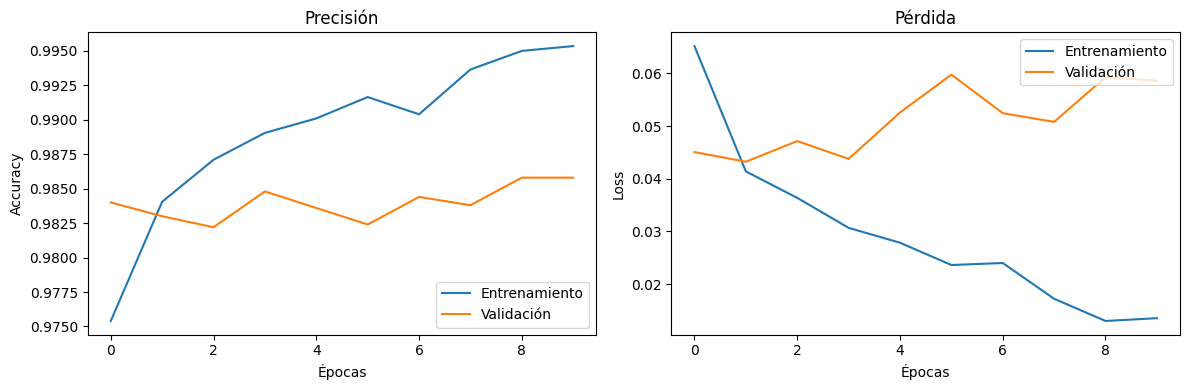

In [7]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']
epochs_range = range(epocas)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Entrenamiento')
plt.plot(epochs_range, val_acc, label='Validación')
plt.legend(loc='lower right')
plt.title('Precisión')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Entrenamiento')
plt.plot(epochs_range, val_loss, label='Validación')
plt.legend(loc='upper right')
plt.title('Pérdida')
plt.xlabel('Épocas')
plt.ylabel('Loss')

plt.tight_layout()
plt.show()

## 6. Guardar el modelo

In [8]:
model.save('modelo_gato_perro.h5')
print("Modelo guardado como 'modelo_gato_perro.h5'")

Modelo guardado como 'modelo_gato_perro.h5'


## 7. Función para predecir imágenes

In [9]:
def predecir_imagen(ruta_imagen):
    img = Image.open(ruta_imagen).convert('RGB').resize((224, 224))
    img_array = np.array(img, dtype=np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    prediccion = model.predict(img_array, verbose=0)
    clases = ['Gato', 'Perro']
    resultado = clases[np.argmax(prediccion)]
    confianza = np.max(prediccion) * 100

    print(f"\nImagen: {ruta_imagen}")
    print(f"Predicción: {resultado}")
    print(f"Confianza: {confianza:.2f}%")
    print(f"Probabilidades - Gato: {prediccion[0][0]:.4f}, Perro: {prediccion[0][1]:.4f}")

    return resultado, confianza

## 8. Probar con imágenes

In [10]:
predecir_imagen("Gatos/1.jpg")
predecir_imagen("Perros/1.jpg")


Imagen: Gatos/1.jpg
Predicción: Gato
Confianza: 100.00%
Probabilidades - Gato: 1.0000, Perro: 0.0000

Imagen: Perros/1.jpg
Predicción: Perro
Confianza: 100.00%
Probabilidades - Gato: 0.0000, Perro: 1.0000


('Perro', np.float32(100.0))